# Current deployed params — 41d backtest

Runs each of the 8 live symbols on its exact deployed config and shows per-symbol + portfolio stats. Same 15m HL data and 0.03% commission as the live bot.

No ensemble, no ML — just what the bot is running today.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings import INSTRUMENTS
from config.deployer import load_all
import research.commod_backtest as cb
from research.ensemble_regime_test import bootstrap, q_pnls, split_stats
from research.current_vs_ensemble import LIVE, _patch_weekday, _cfg_from_deployed, summarize

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('ready')

ready


/Users/lucaneto/Trading/swing-trading-bot/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Run each symbol on its current deployed config, capture trade-level data
dep_all = load_all()
results = {}; trade_log = {}
for sym in LIVE:
    d15 = cb.add_features(cb.fetch_hl(sym, '15m', 4000))
    d1h = cb.add_features(cb.fetch_hl(sym, '1h',  2000))
    d4h = cb.add_features(cb.fetch_hl(sym, '4h',  1000))
    arr = cb.precompute(d15, d1h, d4h)
    _patch_weekday(arr, sym)
    cfg = _cfg_from_deployed(dep_all[sym])
    lev = INSTRUMENTS[sym].hl_max_leverage * 0.15
    trades = cb.backtest(arr, cfg, lev)
    s = summarize(trades)
    s['entry'] = cfg.entry_type; s['exit'] = cfg.exit_type
    s['filter'] = cfg.trend_filter_1h; s['req4h'] = cfg.require_4h_agreement
    results[sym] = s; trade_log[sym] = trades

rows = []
for sym, s in results.items():
    rows.append({'symbol': sym, 'entry': s['entry'], 'exit': s['exit'],
                 'filter_1h': s['filter'], '4h': s['req4h'],
                 'n': s['n'], 'pf': round(s['pf'], 2) if s['pf'] else None,
                 'pnl': round(s['pnl'], 0), 'oos_pnl': round(s['oos_pnl'], 0),
                 'p_win': round(s['p_win'], 2), 'quartiles_pos': s['quarts_pos']})
df = pd.DataFrame(rows).sort_values('pnl', ascending=False)
total_row = pd.DataFrame([{'symbol': 'TOTAL', 'entry': '—', 'exit': '—',
                           'filter_1h': '—', '4h': '', 'n': df['n'].sum(),
                           'pf': '', 'pnl': df['pnl'].sum(), 'oos_pnl': df['oos_pnl'].sum(),
                           'p_win': '', 'quartiles_pos': ''}])
df_full = pd.concat([df, total_row], ignore_index=True)
df_full

,symbol,entry,exit,filter_1h,4h,n,pf,pnl,oos_pnl,p_win,quartiles_pos
0,XRP,bos_structural,bos_hybrid,hma_slope,False,36,2.8,730.0,356.0,0.97,3
1,BTC,regime_flip,regime_flip,hma_slope,False,49,1.2,349.0,162.0,0.65,4
2,HYPE,bos_structural,bos_hybrid,sjm,True,26,1.77,238.0,230.0,0.8,3
3,ZEC,swing_pivot,standard,both_agree,False,44,1.55,231.0,61.0,0.77,3
4,ENA,swing_pivot,standard,both_agree,True,29,2.16,122.0,61.0,0.96,3
5,SOL,bos_structural,bos_hybrid,sjm,False,30,1.21,101.0,126.0,0.63,3
6,xyz:CL,bb_touch,standard,both_agree,False,30,2.13,66.0,43.0,0.94,3
7,kPEPE,bos_structural,bos_structural,sjm,False,25,0.57,-230.0,-70.0,0.13,0
8,TOTAL,—,—,—,,269,,1607.0,969.0,,


## Per-symbol P&L bars

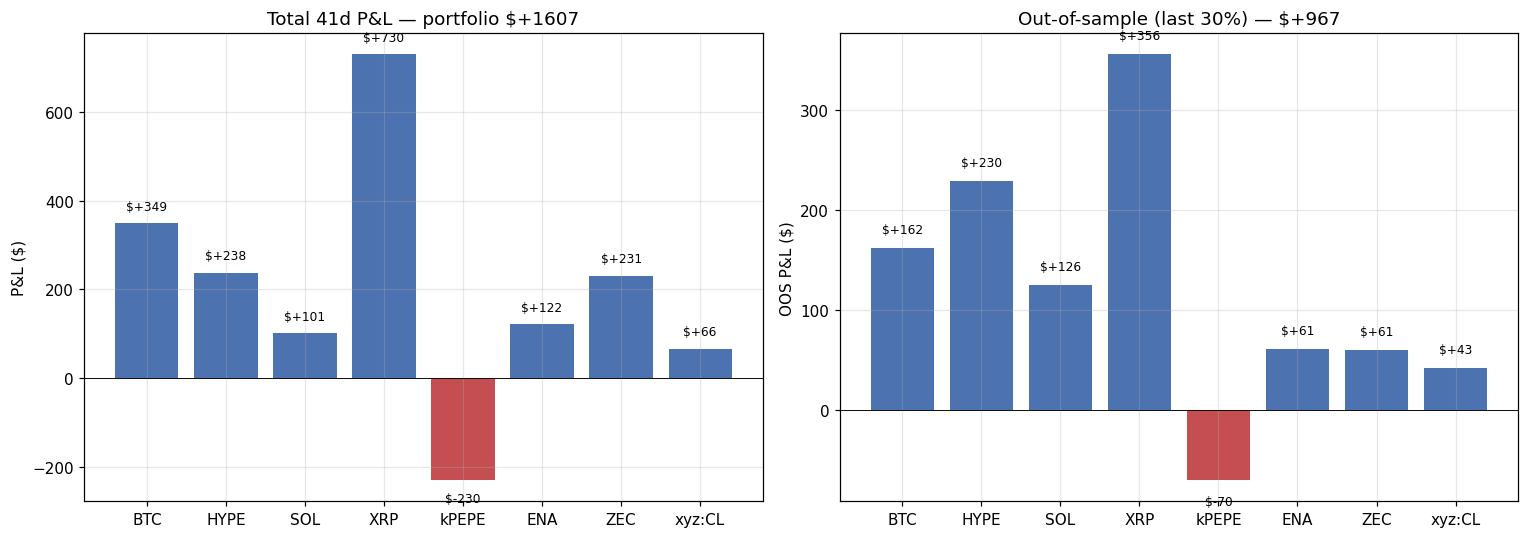

In [3]:
syms = list(results.keys())
pnls = [results[s]['pnl'] for s in syms]
oos  = [results[s]['oos_pnl'] for s in syms]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0' if v >= 0 else '#C44E52' for v in pnls]
ax[0].bar(syms, pnls, color=colors)
ax[0].axhline(0, color='k', lw=0.6); ax[0].set_ylabel('P&L ($)')
ax[0].set_title(f'Total 41d P&L — portfolio ${sum(pnls):+.0f}')
for i, v in enumerate(pnls):
    ax[0].text(i, v + (30 if v >= 0 else -50), f'${v:+.0f}', ha='center', fontsize=8)

colors_oos = ['#4C72B0' if v >= 0 else '#C44E52' for v in oos]
ax[1].bar(syms, oos, color=colors_oos)
ax[1].axhline(0, color='k', lw=0.6); ax[1].set_ylabel('OOS P&L ($)')
ax[1].set_title(f'Out-of-sample (last 30%) — ${sum(oos):+.0f}')
for i, v in enumerate(oos):
    ax[1].text(i, v + (15 if v >= 0 else -25), f'${v:+.0f}', ha='center', fontsize=8)

plt.tight_layout(); plt.show()

## Portfolio equity curve + drawdown

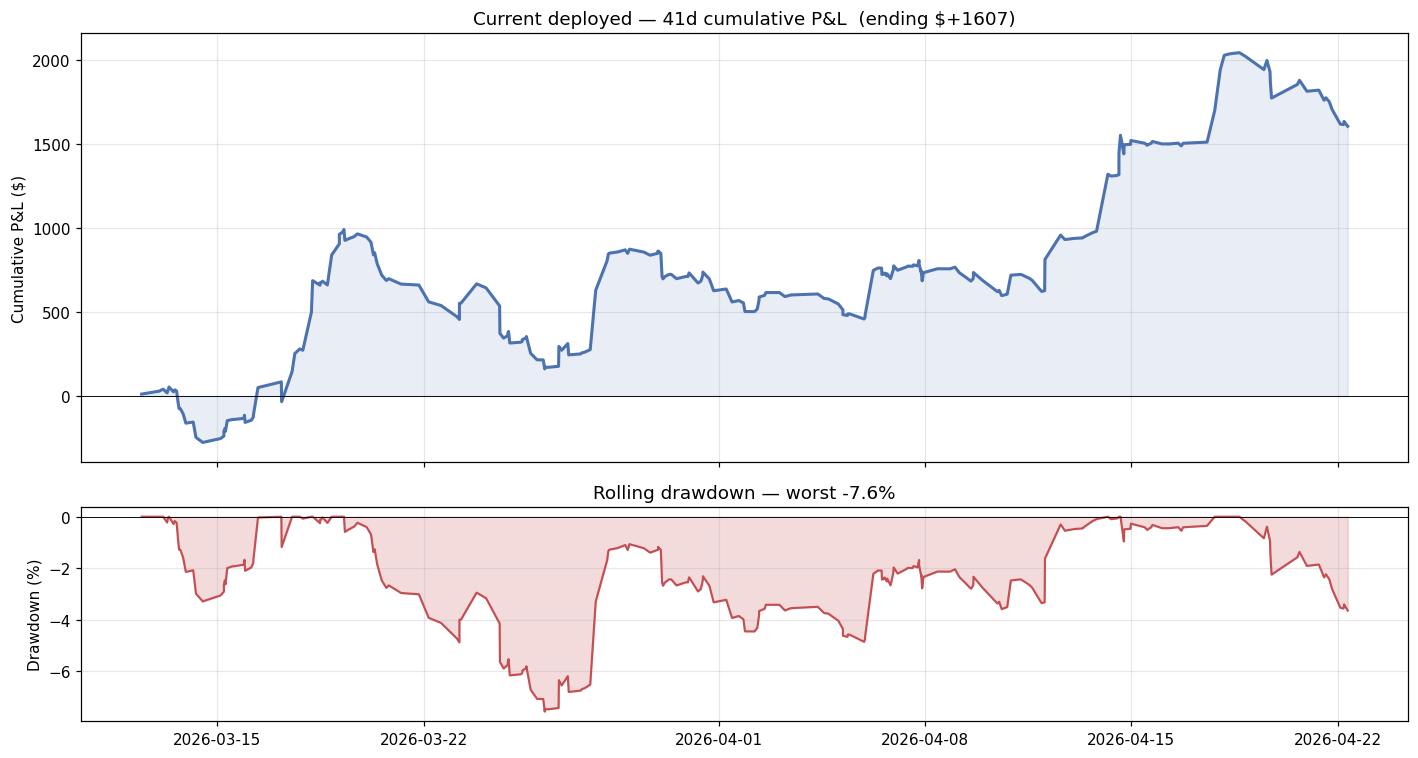

In [4]:
all_tr = []
for sym, trades in trade_log.items():
    for t in trades:
        all_tr.append({'ts': pd.Timestamp(t['ts']), 'pnl': t['pnl'], 'sym': sym})
eq = pd.DataFrame(all_tr).sort_values('ts')
eq['cum'] = eq['pnl'].cumsum()
eq = eq.set_index('ts')

def drawdown(cum):
    equity = 10000 + cum
    peak = equity.cummax()
    return (equity - peak) / peak * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(eq.index, eq['cum'], color='#4C72B0', lw=2)
axes[0].fill_between(eq.index, eq['cum'], 0, alpha=0.12, color='#4C72B0')
axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].set_title(f'Current deployed — 41d cumulative P&L  (ending ${eq["cum"].iloc[-1]:+.0f})')

dd = drawdown(eq['cum'])
axes[1].plot(dd.index, dd.values, color='#C44E52', lw=1.4)
axes[1].fill_between(dd.index, dd.values, 0, alpha=0.2, color='#C44E52')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title(f'Rolling drawdown — worst {dd.min():.1f}%')
plt.tight_layout(); plt.show()

## Monthly return table

In [5]:
eq_by_week = eq.copy()
eq_by_week['week'] = eq_by_week.index.isocalendar().week
wk = eq_by_week.groupby('week')['pnl'].sum().reset_index()
wk['cumulative'] = wk['pnl'].cumsum()
wk['pnl'] = wk['pnl'].round(2)
wk['cumulative'] = wk['cumulative'].round(2)
wk

,week,pnl,cumulative
0,11,-157.64,-157.64
1,12,696.59,538.95
2,13,323.06,862.01
3,14,-384.06,477.95
4,15,453.77,931.72
5,16,843.06,1774.79
6,17,-168.08,1606.70
